# Feature Engineering EDA

This notebook compares raw toilet logs and engineered feature distributions for reporting.

In [27]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [28]:
db_path = os.path.abspath(os.path.join('..', 'hospital_iot.db'))
print(f'DB path: {db_path}')

conn = sqlite3.connect(db_path)

raw_df = pd.read_sql_query('SELECT * FROM Toilet_Logs', conn)
feat_df = pd.read_sql_query('SELECT * FROM Toilet_Log_Features', conn)
tod_df = pd.read_sql_query('SELECT * FROM TimeOfDay', conn)

conn.close()

print('Raw rows:', len(raw_df))
print('Feature rows:', len(feat_df))
print('Raw columns:', list(raw_df.columns))
print('Feature columns:', list(feat_df.columns))

DB path: c:\Users\c0077\OneDrive - The Hong Kong Polytechnic University\Documents\study\FYP\Code\Backend\hospital_iot.db
Raw rows: 18590
Feature rows: 18484
Raw columns: ['log_id', 'patient_id', 'entry_time', 'exit_time', 'duration_seconds', 'time_of_day_id', 'is_accident', 'created_at', 'updated_at']
Feature columns: ['feature_id', 'log_id', 'patient_id', 'duration_seconds', 'time_of_day_id', 'hour_of_day', 'day_of_week', 'is_weekend', 'time_since_last_log_minutes', 'is_accident', 'mean_duration_7d', 'max_duration_7d', 'min_duration_7d', 'std_duration_7d', 'log_count_7d', 'tod_deep_night_count_7d', 'tod_early_morning_count_7d', 'tod_late_morning_count_7d', 'tod_afternoon_count_7d', 'tod_evening_count_7d', 'accident_ratio_7d', 'age_x_mobility', 'gastro_x_duration', 'age', 'gender', 'mobility_level', 'has_gastro_issue', 'has_uro_issue', 'self_reported_max_seconds', 'report_minus_duration', 'duration_to_report_ratio', 'created_at']


In [29]:
raw_df['entry_time'] = pd.to_datetime(raw_df['entry_time'], errors='coerce')
raw_df['exit_time'] = pd.to_datetime(raw_df['exit_time'], errors='coerce')

print('Raw null counts:')
print(raw_df.isnull().sum().sort_values(ascending=False).head(10))

print('Feature null counts:')
print(feat_df.isnull().sum().sort_values(ascending=False).head(10))

Raw null counts:
log_id              0
patient_id          0
entry_time          0
exit_time           0
duration_seconds    0
time_of_day_id      0
is_accident         0
created_at          0
updated_at          0
dtype: int64
Feature null counts:
feature_id                     0
log_id                         0
patient_id                     0
duration_seconds               0
time_of_day_id                 0
hour_of_day                    0
day_of_week                    0
is_weekend                     0
time_since_last_log_minutes    0
is_accident                    0
dtype: int64


Duration summary (raw):
count    18590.000000
mean       885.644863
std        565.433701
min          0.000000
25%        500.000000
50%        765.000000
75%       1111.000000
max       5822.000000
Name: duration_seconds, dtype: float64


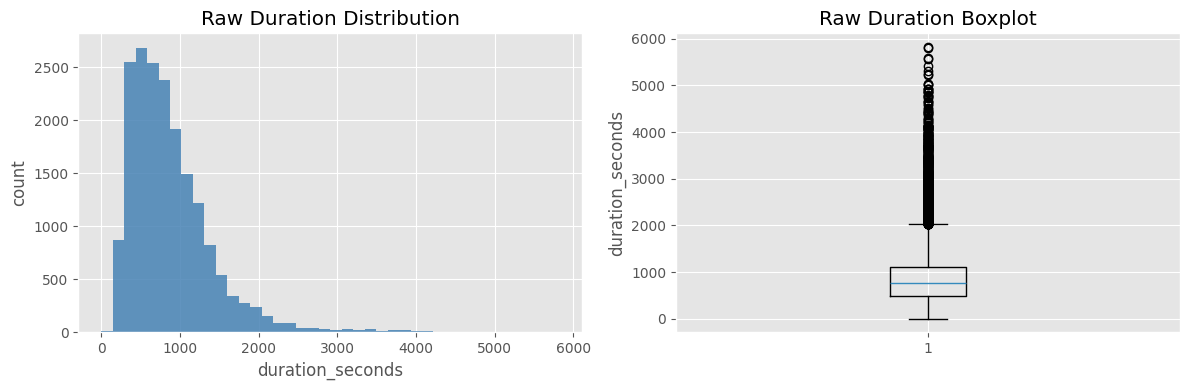

In [30]:
print('Duration summary (raw):')
print(raw_df['duration_seconds'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw_df['duration_seconds'].dropna(), bins=40, color='steelblue', alpha=0.85)
axes[0].set_title('Raw Duration Distribution')
axes[0].set_xlabel('duration_seconds')
axes[0].set_ylabel('count')

axes[1].boxplot(raw_df['duration_seconds'].dropna(), vert=True)
axes[1].set_title('Raw Duration Boxplot')
axes[1].set_ylabel('duration_seconds')

plt.tight_layout()
plt.show()

Feature summary:
       mean_duration_7d  std_duration_7d  time_since_last_log_minutes  \
count      18484.000000     18484.000000                 18484.000000   
mean         886.369274       451.245691                   230.877516   
std          287.942478       192.949485                   237.156337   
min          261.000000         0.000000                     0.000000   
25%          663.365354       316.799932                    59.000000   
50%          848.554580       419.428013                   148.000000   
75%         1033.600681       559.989290                   327.000000   
max         4866.000000      1827.556170                  1501.000000   

       accident_ratio_7d  log_count_7d  report_minus_duration  \
count       18484.000000  18484.000000           18484.000000   
mean            0.026753     38.244536            1224.248918   
std             0.031427     11.359483             565.912176   
min             0.000000      1.000000           -2552.000000   


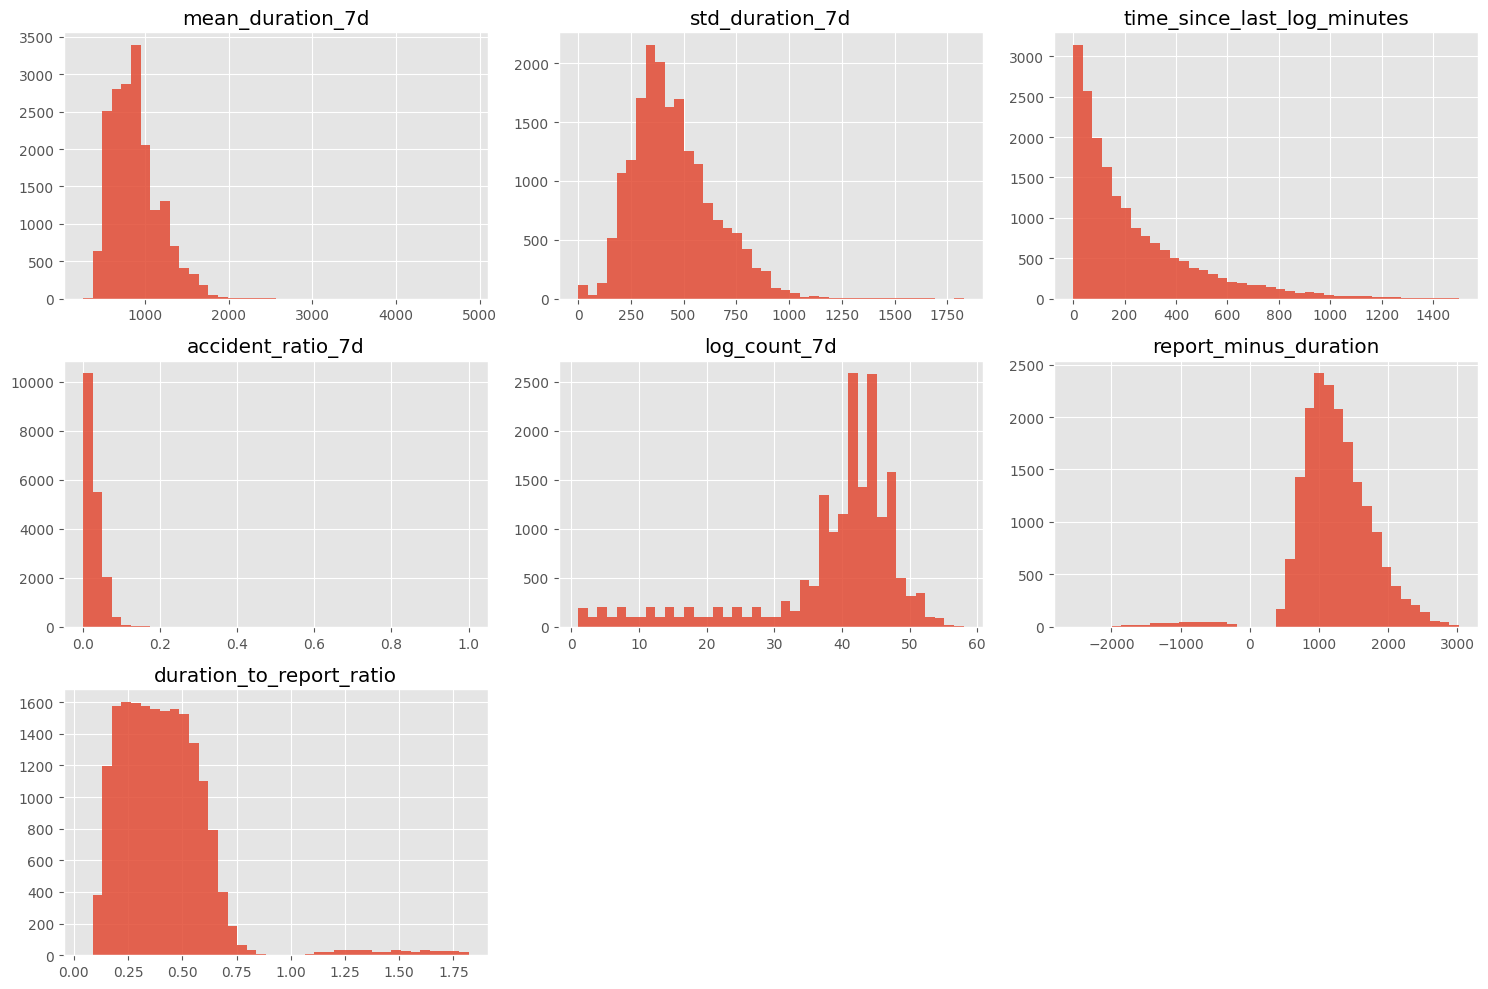

In [31]:
feature_cols = [
    'mean_duration_7d',
    'std_duration_7d',
    'time_since_last_log_minutes',
    'accident_ratio_7d',
    'log_count_7d',
    'report_minus_duration',
    'duration_to_report_ratio',
]

print('Feature summary:')
print(feat_df[feature_cols].describe())

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(feat_df[col].dropna(), bins=40, alpha=0.85)
    axes[i].set_title(col)

for i in range(len(feature_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

                raw_count  feature_count
time_of_day_id                          
Afternoon            3645           3644
Deep Night           2883           2814
Early Morning        5570           5535
Evening              2818           2818
Late Morning         3674           3673


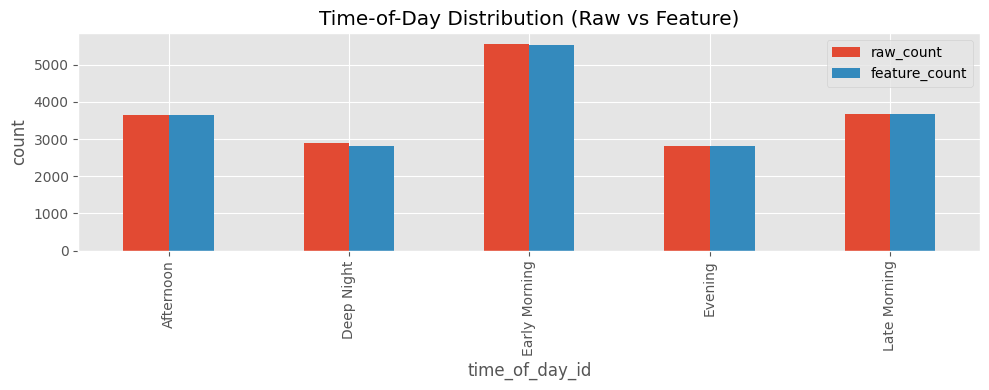

In [32]:
tod_map = dict(zip(tod_df['id'], tod_df['label']))

raw_tod_counts = raw_df['time_of_day_id'].map(tod_map).value_counts()
feat_tod_counts = feat_df['time_of_day_id'].map(tod_map).value_counts()

compare_tod = pd.DataFrame({
    'raw_count': raw_tod_counts,
    'feature_count': feat_tod_counts
}).fillna(0).astype(int)

print(compare_tod)
compare_tod.plot(kind='bar', figsize=(10, 4), title='Time-of-Day Distribution (Raw vs Feature)')
plt.ylabel('count')
plt.tight_layout()
plt.show()

Patient-level mean_duration_7d summary:
count     100.000000
mean      885.063279
std       271.732953
min       426.121167
25%       662.224786
50%       867.853996
75%      1025.223744
max      1593.265008
Name: mean_duration_7d, dtype: float64


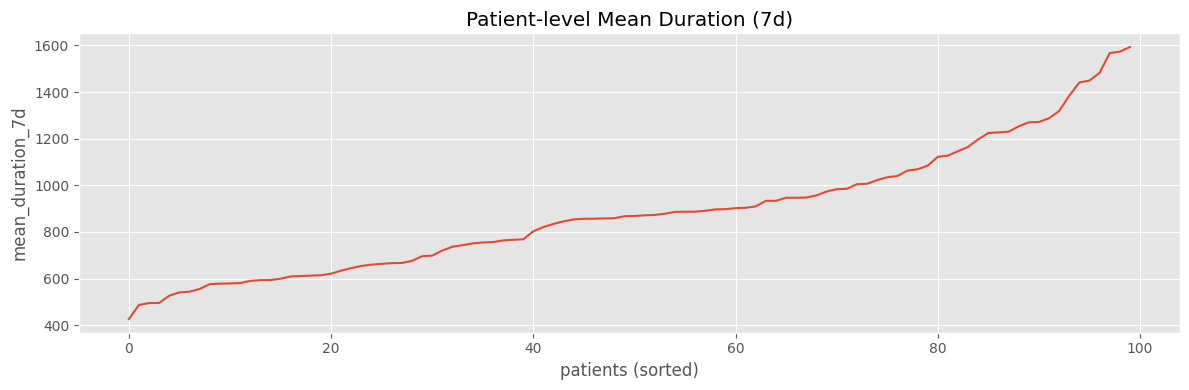

In [33]:
patient_mean = feat_df.groupby('patient_id')['mean_duration_7d'].mean().sort_values()

print('Patient-level mean_duration_7d summary:')
print(patient_mean.describe())

plt.figure(figsize=(12, 4))
plt.plot(patient_mean.values)
plt.title('Patient-level Mean Duration (7d)')
plt.xlabel('patients (sorted)')
plt.ylabel('mean_duration_7d')
plt.tight_layout()
plt.show()

In [34]:
raw_n = len(raw_df)
feat_n = len(feat_df)
dropped = raw_n - feat_n
drop_ratio = dropped / raw_n if raw_n > 0 else np.nan

print(f'Raw rows: {raw_n}')
print(f'Feature rows: {feat_n}')
print(f'Dropped cold-start rows: {dropped}')
print(f'Drop ratio: {drop_ratio:.4f}')

Raw rows: 18590
Feature rows: 18484
Dropped cold-start rows: 106
Drop ratio: 0.0057


In [35]:
print('Raw table columns (before feature engineering):')
print(f'Total columns: {len(raw_df.columns)}')
for i, c in enumerate(raw_df.columns, 1):
    print(f'{i:02d}. {c}')

Raw table columns (before feature engineering):
Total columns: 9
01. log_id
02. patient_id
03. entry_time
04. exit_time
05. duration_seconds
06. time_of_day_id
07. is_accident
08. created_at
09. updated_at


In [36]:
print('Feature table columns (after feature engineering):')
print(f'Total columns: {len(feat_df.columns)}')
for i, c in enumerate(feat_df.columns, 1):
    print(f'{i:02d}. {c}')

Feature table columns (after feature engineering):
Total columns: 32
01. feature_id
02. log_id
03. patient_id
04. duration_seconds
05. time_of_day_id
06. hour_of_day
07. day_of_week
08. is_weekend
09. time_since_last_log_minutes
10. is_accident
11. mean_duration_7d
12. max_duration_7d
13. min_duration_7d
14. std_duration_7d
15. log_count_7d
16. tod_deep_night_count_7d
17. tod_early_morning_count_7d
18. tod_late_morning_count_7d
19. tod_afternoon_count_7d
20. tod_evening_count_7d
21. accident_ratio_7d
22. age_x_mobility
23. gastro_x_duration
24. age
25. gender
26. mobility_level
27. has_gastro_issue
28. has_uro_issue
29. self_reported_max_seconds
30. report_minus_duration
31. duration_to_report_ratio
32. created_at


In [37]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add Backend directory to path to import ml_preprocessing and Scripts.initial_training
sys.path.append(os.path.abspath(os.path.join('..')))

from ml_preprocessing import load_config, create_preprocessor, get_feature_names_after_preprocessing
from Scripts.initial_training import prepare_features

# 1. Load config.yaml
config = load_config()

# 2. Get features X and label y 
# We use 'all' strategy here purely for EDA to visualize the correlation of ALL features.
# (Note: actual model training uses 'filtered' strategy to prevent data leakage)
X, y, feature_cols = prepare_features(feat_df, config, strategy='all')

# 3. Get preprocessor (ColumnTransformer)
preprocessor, numerical_cols, categorical_cols = create_preprocessor(X, config)

# 4. Train-test split based on config
train_ratio = config['data']['train_ratio']
split_idx = int(len(X) * train_ratio)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 5. Fit & Transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print('=== Preprocessing Complete ===')
print(f'Train rows: {len(X_train)}  |  Test rows: {len(X_test)}')
print(f'Number of features used: {len(feature_cols)} (Using ALL features for EDA)')
print(f'\nCategorical cols ({len(categorical_cols)}) -- one-hot encoded:')
for c in categorical_cols:
    print(f'  {c}')

Feature matrix: (18484, 27)
Label distribution:
is_accident
0    0.973112
1    0.026888
Name: proportion, dtype: float64
=== Preprocessing Complete ===
Train rows: 14787  |  Test rows: 3697
Number of features used: 27 (Using ALL features for EDA)

Categorical cols (7) -- one-hot encoded:
  time_of_day_id
  day_of_week
  is_weekend
  mobility_level
  has_gastro_issue
  has_uro_issue
  gender


## Accident Classification Preprocessing
Prepare features for classification with one-hot encoding (categorical) and standardization (numerical).

=== Standardized Features vs Label (Pearson correlation) ===
                         feature  pearson_corr_with_is_accident  abs_corr
   num__duration_to_report_ratio                       0.687845  0.687845
      num__report_minus_duration                      -0.579908  0.579908
           num__duration_seconds                       0.577272  0.577272
          num__gastro_x_duration                       0.136827  0.136827
           cat__time_of_day_id_1                       0.128385  0.128385
                num__hour_of_day                      -0.075765  0.075765
           cat__time_of_day_id_3                      -0.055116  0.055116
           cat__time_of_day_id_4                      -0.037434  0.037434
            num__std_duration_7d                      -0.026108  0.026108
          num__accident_ratio_7d                      -0.025212  0.025212
            num__max_duration_7d                      -0.024520  0.024520
num__time_since_last_log_minutes                   

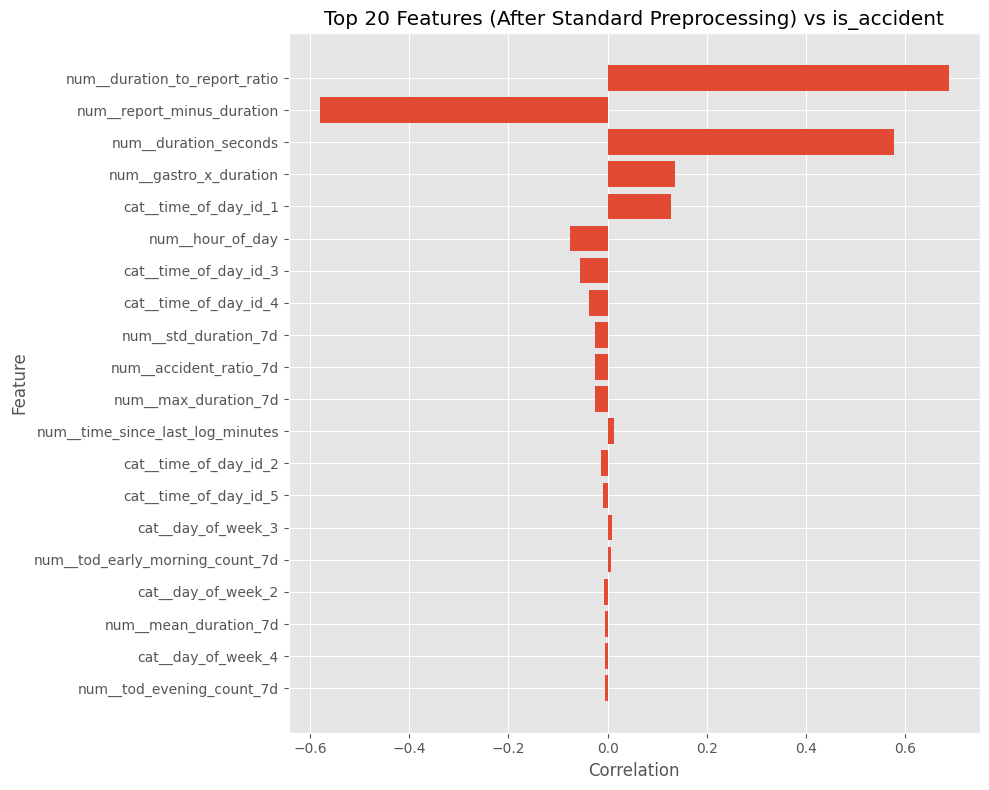

In [38]:
# Get final column names from the Preprocessor
processed_feature_names = get_feature_names_after_preprocessing(preprocessor)
processed_feature_names = pd.Index(processed_feature_names).astype(str)

# Convert numpy matrix back to DataFrame for plotting and analysis
processed_train_df = pd.DataFrame(
    X_train_processed.toarray() if hasattr(X_train_processed, 'toarray') else X_train_processed,
    columns=processed_feature_names,
    index=X_train.index,
)

# Append target label to calculate correlation
processed_train_df[config['data']['label_col']] = y_train

label_col = config['data']['label_col']
if processed_train_df[label_col].nunique(dropna=True) < 2:
    print(f"Warning: '{label_col}' has only one class. Pearson correlation is undefined.")
    corr_series = pd.Series(0.0, index=[c for c in processed_train_df.columns if c != label_col])
else:
    corr_series = processed_train_df.corr(numeric_only=True)[label_col].drop(labels=[label_col], errors='ignore')
    corr_series = corr_series.fillna(0.0)

result = pd.DataFrame({
    'feature': corr_series.index,
    'pearson_corr_with_is_accident': corr_series.values,
    'abs_corr': np.abs(corr_series.values)
}).sort_values('abs_corr', ascending=False)

print('=== Standardized Features vs Label (Pearson correlation) ===')
print(result.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
plot_df = result.head(20).iloc[::-1]
plt.barh(plot_df['feature'], plot_df['pearson_corr_with_is_accident'])
plt.title('Top 20 Features (After Standard Preprocessing) vs is_accident')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [39]:
all_processed_cols_df = pd.DataFrame({
    'idx': np.arange(1, len(processed_feature_names) + 1),
    'column_name': processed_feature_names
})

pd.set_option('display.max_rows', None)
print(f'Total {len(processed_feature_names)} processed feature columns:')
print(all_processed_cols_df.to_string(index=False))

Total 43 processed feature columns:
 idx                      column_name
   1            num__duration_seconds
   2                 num__hour_of_day
   3 num__time_since_last_log_minutes
   4            num__mean_duration_7d
   5             num__max_duration_7d
   6             num__min_duration_7d
   7             num__std_duration_7d
   8                num__log_count_7d
   9     num__tod_deep_night_count_7d
  10  num__tod_early_morning_count_7d
  11   num__tod_late_morning_count_7d
  12      num__tod_afternoon_count_7d
  13        num__tod_evening_count_7d
  14           num__accident_ratio_7d
  15              num__age_x_mobility
  16           num__gastro_x_duration
  17                         num__age
  18   num__self_reported_max_seconds
  19       num__report_minus_duration
  20    num__duration_to_report_ratio
  21            cat__time_of_day_id_1
  22            cat__time_of_day_id_2
  23            cat__time_of_day_id_3
  24            cat__time_of_day_id_4
  25          